In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

matplotlib.rcParams['figure.dpi'] = 150

# Daten laden
X_train   = pd.read_csv('../data/X_train.csv')
X_test    = pd.read_csv('../data/X_test.csv')
y_train   = pd.read_csv('../data/y_train.csv').squeeze()
y_test    = pd.read_csv('../data/y_test.csv').squeeze()
sex_test  = pd.read_csv('../data/sex_test.csv').squeeze()
race_test = pd.read_csv('../data/race_test.csv').squeeze()

print("Daten geladen.")
print("Gruppenverteilung race_test:")
print(race_test.value_counts())

Daten geladen.
Gruppenverteilung race_test:
race
White                 5568
Black                  625
Asian-Pac-Islander     201
Amer-Indian-Eskimo      65
Other                   54
Name: count, dtype: int64


In [2]:
# Baseline-Modell trainieren (identisch zu Notebook 02)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Modell trainiert.")

Modell trainiert.


In [3]:
# Intersektionale Gruppen definieren
gruppen = {
    'Weiße Männer':    (race_test == 'White') & (sex_test == 1),
    'Weiße Frauen':    (race_test == 'White') & (sex_test == 0),
    'Schwarze Männer': (race_test == 'Black') & (sex_test == 1),
    'Schwarze Frauen': (race_test == 'Black') & (sex_test == 0),
}

# Kennzahlen berechnen
referenz_rate = y_pred[gruppen['Weiße Männer']].mean()

ergebnisse = []
for name, maske in gruppen.items():
    n        = maske.sum()
    pos_rate = y_pred[maske].mean()
    dir_val  = pos_rate / referenz_rate
    ergebnisse.append({
        'Gruppe':                    name,
        'n (Testdaten)':             n,
        'Positive Rate':             round(pos_rate, 4),
        'DIR (vs. Weiße Männer)':    round(dir_val, 4)
    })

df_results = pd.DataFrame(ergebnisse)
print(df_results.to_string(index=False))
df_results.to_csv('../results/tables/intersektional_results.csv', index=False)
print("---")
print("Tabelle gespeichert.")

         Gruppe  n (Testdaten)  Positive Rate  DIR (vs. Weiße Männer)
   Weiße Männer           3836         0.2831                  1.0000
   Weiße Frauen           1732         0.0964                  0.3406
Schwarze Männer            320         0.1469                  0.5188
Schwarze Frauen            305         0.0459                  0.1621
---
Tabelle gespeichert.


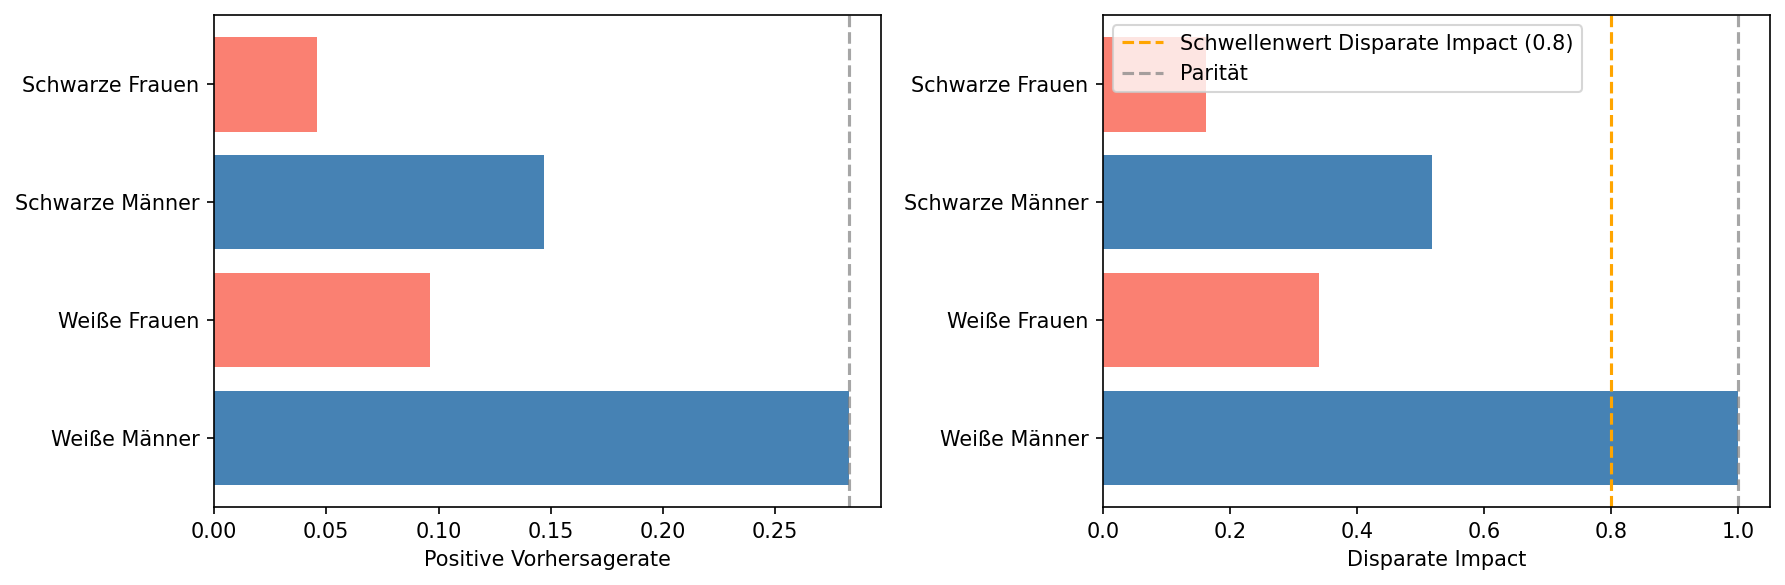

Abbildung gespeichert.


In [4]:
# Visualisierung speichern
gruppen_namen = [r['Gruppe'] for r in ergebnisse]
pos_raten     = [r['Positive Rate'] for r in ergebnisse]
dir_werte     = [r['DIR (vs. Weiße Männer)'] for r in ergebnisse]
farben        = ['steelblue', 'salmon', 'steelblue', 'salmon']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Positive Raten
axes[0].barh(gruppen_namen, pos_raten, color=farben)
axes[0].axvline(x=referenz_rate, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Positive Vorhersagerate')
# axes[0].set_title('Positive Raten nach Gruppe')

# Plot 2: DIR
axes[1].barh(gruppen_namen, dir_werte, color=farben)
axes[1].axvline(x=0.8, color='orange', linestyle='--',
                label='Schwellenwert Disparate Impact (0.8)')
axes[1].axvline(x=1.0, color='gray', linestyle='--',
                alpha=0.7, label='Parität')
axes[1].set_xlabel('Disparate Impact')
# axes[1].set_title('DIR nach Gruppe (Referenz: Weiße Männer)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/intersektional.png', bbox_inches='tight')
plt.show()
print("Abbildung gespeichert.")